#  Fake News Detection Project

Ce projet consiste à détecter automatiquement les fausses informations (Fake News) à l'aide de techniques de Machine Learning 

Avec l’augmentation des informations en ligne, il devient essentiel de distinguer les vraies informations des fausses.

![fake-news-hero-img](fake-news-hero-img.jpg)

---

##  Table des matières

| # | Section | Description |
|---|---------|-------------|
| 1 | [Contexte & Problématique](#contexte) | Motivation, enjeux et objectifs du projet |
| 2 | [Installation & Imports](#imports) | Dépendances et bibliothèques Python |
| 3 | [Chargement des données](#chargement) | Lecture des fichiers Fake.csv et True.csv |
| 4 | [Préparation des données](#preparation) | Labels, fusion, échantillonnage aléatoire |
| 5 | [Analyse Exploratoire — EDA](#eda) | Distribution, WordCloud, sujets thématiques |
| 6 | [Contrôle qualité](#qualite) | Déséquilibres, doublons, valeurs manquantes |
| 7 | [Prétraitement NLP](#nlp) | Nettoyage textuel, tokenisation, stopwords |
| 8 | [Vectorisation TF-IDF](#tfidf) | Représentation numérique du texte |
| 9 | [Modèle 1 — Naive Bayes](#naivebayes) | Multinomial Naive Bayes (baseline) |
| 10 | [Modèle 2 — XGBoost](#xgboost) | Extreme Gradient Boosting |
| 11 | [Modèle 3 — SGDClassifier](#sgd) | Stochastic Gradient Descent |
| 12 | [Modèle 4 — SVM](#svm) | Support Vector Machine (LinearSVC) |
| 13 | [Modèle 5 — Decision Tree](#decisiontree) | Arbre de Décision (Gini) |
| 14 | [Modèle 6 — Random Forest](#randomforest) | Forêt Aléatoire (Ensemble) |
| 15 | [Modèle 7 — Logistic Regression](#logisticregression) | Régression Logistique |
| 16 | [Comparaison & Conclusion](#comparaison) | Synthèse des 7 modèles et perspectives |
| 17 | [Test manuel](#test_manuel) | Validation humaine sur 20 articles inédits |
| 18 | [Sauvegarde des modèles](#sauvegarde) | Export joblib des 7 modèles et du vectoriseur |
| 19 | [Conclusion générale](#conclusion) | Synthèse, points forts et perspectives |

---


---

<a id="contexte"></a>

## 1. Contexte & Problématique

<div style="background:#fff8e1; border-left:5px solid #f9a825; border-radius:8px; padding:16px 22px; margin:16px 0;">
 <strong>Enjeu sociétal :</strong> La prolifération des fausses informations constitue une menace croissante pour la démocratie et la santé publique. Les contenus trompeurs se propagent jusqu'à <strong>6 fois plus vite</strong> que les informations vérifiées sur les réseaux sociaux.
</div>

### 1.1 Motivation

Avec l'explosion du volume d'informations en ligne, la vérification manuelle des contenus est devenue **impossible à grande échelle**. Le traitement automatique du langage naturel (NLP) et l'apprentissage automatique offrent des solutions prometteuses pour automatiser cette détection.

### 1.2 Objectif

Concevoir un **pipeline complet de détection de fake news** — de l'ingestion des données brutes jusqu'à la comparaison de modèles de classification — en suivant les bonnes pratiques de la Data Science académique.

| Classe | Label | Description |
|--------|-------|-------------|
| `0` | **FAKE** | Article de désinformation |
| `1` | **TRUE** | Article d'information vérifiée |

### 1.3 Pipeline général

```
Données brutes ──► EDA ──► Nettoyage NLP ──► TF-IDF ──► Modèles ML ──► Évaluation
```

---

<a id="imports"></a>

## 2. Installation & Importation des bibliothèques

Installation des dépendances non standard, puis importation de tous les modules nécessaires au projet.

In [1]:
!pip install wordcloud xgboost --quiet


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: C:\Users\MON_PC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
# ── Manipulation des données ─────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud

# ── NLP ───────────────────────────────────────────────────────────────
import re
import string
import nltk

# ── Machine Learning ──────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# ── Configuration globale ─────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('Toutes les bibliothèques importées avec succès.')


Toutes les bibliothèques importées avec succès.


---

<a id="chargement"></a>

## 3. Chargement des données

Le dataset utilisé est le **ISOT Fake News Dataset** (Université de Victoria), composé de deux fichiers CSV :

| Fichier | Contenu | Source |
|---------|---------|--------|
| `Fake.csv` | Articles de désinformation | Sites web non fiables |
| `True.csv` | Articles vérifiés | Reuters.com |

Chaque article contient les colonnes `title`, `text`, `subject` et `date`.

In [5]:
import pandas as pd

df_fake = pd.read_csv("Fake.csv")
df_true = pd.read_csv("True.csv")

print('── Fake News Dataset ──')
print(f'Dimensions : {df_fake.shape}  |  Colonnes : {list(df_fake.columns)}')
display(df_fake.head(3))

print('\n── True News Dataset ──')
print(f'Dimensions : {df_true.shape}  |  Colonnes : {list(df_true.columns)}')
display(df_true.head(3))

── Fake News Dataset ──
Dimensions : (23481, 4)  |  Colonnes : ['title', 'text', 'subject', 'date']


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"



── True News Dataset ──
Dimensions : (21417, 4)  |  Colonnes : ['title', 'text', 'subject', 'date']


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"


---

<a id="preparation"></a>

## 4. Préparation des données

### 4.1 Ajout des étiquettes (labels)

On encode la variable cible de manière binaire : `0` pour les articles **faux**, `1` pour les articles **vrais**.

In [7]:
df_fake["class"] = 0  # FAKE
df_true["class"] = 1  # TRUE

print(f' Labels ajoutés — df_fake : {df_fake.shape}, df_true : {df_true.shape}')

 Labels ajoutés — df_fake : (23481, 5), df_true : (21417, 5)


### 4.2 Mise de côté d'un ensemble de test manuel

Les **10 dernières lignes** de chaque dataset sont extraites pour une validation humaine ultérieure, avant d'être retirées du corpus d'entraînement.

In [9]:

df_fake_manual_testing = df_fake.tail(10)
for i in range(23480,23470,-1):
    df_fake.drop([i], axis = 0, inplace = True)
    
    
df_true_manual_testing = df_true.tail(10)
for i in range(21416,21406,-1):
    df_true.drop([i], axis = 0, inplace = True)

### 4.3 Fusion et mélange aléatoire

Les deux datasets sont concaténés puis **mélangés aléatoirement** (`random_state=42` pour la reproductibilité), afin d'éviter tout biais d'ordre lors de l'entraînement.

In [11]:
df = pd.concat([df_fake, df_true])
df = df.sample(frac=1, random_state=42)
df.reset_index(drop=True, inplace=True)

# Sauvegarde du dataset fusionné
df.to_csv('dataset_final.csv', index=False)

print(f'dataset_final.csv sauvegardé — {len(df):,} lignes, {df.shape[1]} colonnes')
print(f'   Fake (0) : {(df["class"]==0).sum():,}')
print(f'   Real (1) : {(df["class"]==1).sum():,}')


dataset_final.csv sauvegardé — 44,878 lignes, 5 colonnes
   Fake (0) : 23,471
   Real (1) : 21,407


In [12]:
print('Aperçu du dataset fusionné :')
display(df.head())
print(f'\nDistribution des classes :')
print(df['class'].value_counts().rename({0: 'FAKE (0)', 1: 'TRUE (1)'}))

Aperçu du dataset fusionné :


,title,text,subject,date,class
0,White House Officials Admit That Trump LIED A...,Donald Trump has been bragging about his inaug...,News,"January 21, 2017",0
1,Egypt says bombs militants responsible for Wes...,CAIRO (Reuters) - Egypt s air force killed a l...,worldnews,"October 31, 2017",1
2,OUTRAGEOUS! Intimidation of Citizens Opposed t...,"A press release by Bernards Township, NJ is pr...",Government News,"Mar 28, 2017",0
3,AS TRUMP’S POPULARITY SOARS ABROAD…Village In ...,President Donald Trump welcomed India s Prime ...,left-news,"Jun 27, 2017",0
4,"Lebanon ex-PM meets French, UK, EU, U.S. diplo...","BEIRUT (Reuters) - Saad al-Hariri, who resigne...",worldnews,"November 9, 2017",1



Distribution des classes :
class
FAKE (0)    23471
TRUE (1)    21407
Name: count, dtype: int64


---

<a id="eda"></a>

## 5. Analyse Exploratoire des Données (EDA)

L'EDA vise à comprendre la **structure du dataset**, la distribution des classes et le vocabulaire caractéristique de chaque catégorie avant toute modélisation.

### 5.1 Distribution Fake vs True

Visualisation de l'équilibre entre les deux classes via un graphique en barres et un diagramme circulaire.

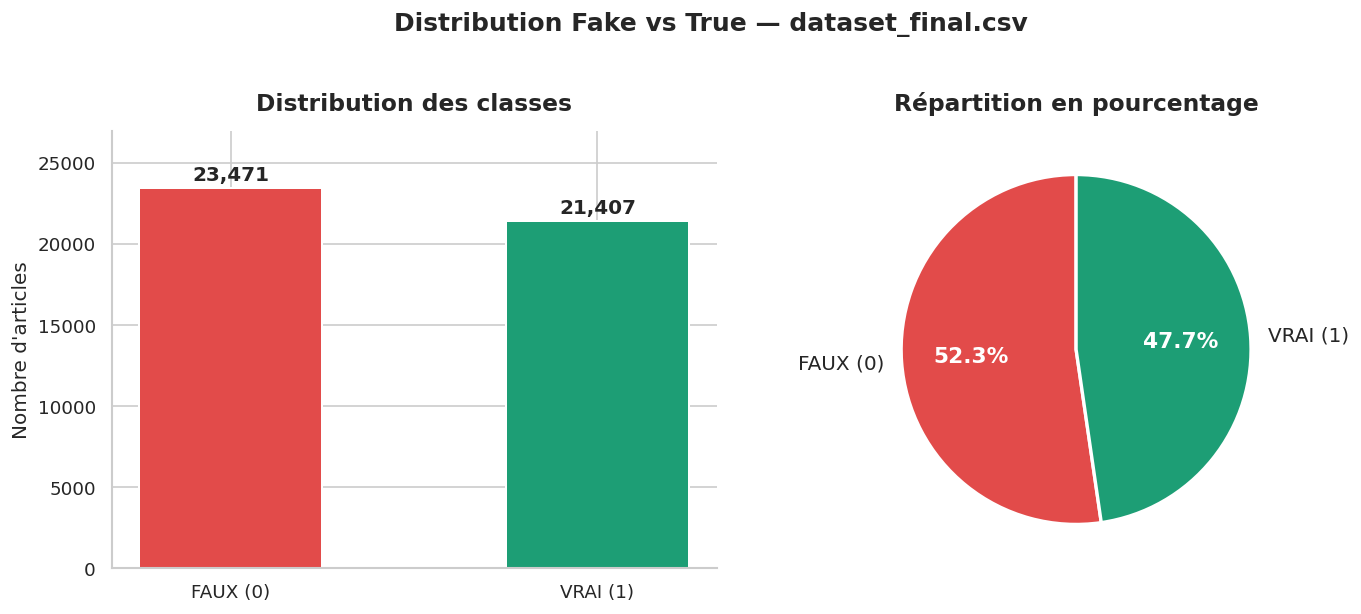

FAUX : 23,471 articles (52.3%)
VRAI : 21,407 articles (47.7%)
 Dataset bien équilibré (ratio < 2:1) → pas besoin de rééchantillonnage


In [14]:
counts = df['class'].value_counts().sort_index()
labels_names = ['FAUX (0)', 'VRAI (1)']
colors = ['#E24B4A', '#1D9E75']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Barres ---
bars = axes[0].bar(labels_names, counts.values, color=colors,
                   width=0.5, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribution des classes', fontsize=14, fontweight='bold', pad=12)
axes[0].set_ylabel('Nombre d\'articles')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(counts.values) * 1.15)
axes[0].spines[['top','right']].set_visible(False)

# --- Camembert ---
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=labels_names, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2},
    textprops={'fontsize':12}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
    at.set_color('white')
axes[1].set_title('Répartition en pourcentage', fontsize=14, fontweight='bold', pad=12)

plt.suptitle('Distribution Fake vs True — dataset_final.csv',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_distribution.png', bbox_inches='tight')
plt.show()

print(f'FAUX : {counts[0]:,} articles ({counts[0]/len(df)*100:.1f}%)')
print(f'VRAI : {counts[1]:,} articles ({counts[1]/len(df)*100:.1f}%)')
print(' Dataset bien équilibré (ratio < 2:1) → pas besoin de rééchantillonnage')

### 5.2 WordCloud — Vocabulaire caractéristique

Les nuages de mots permettent d'identifier visuellement les **termes les plus fréquents** dans chaque classe, après suppression des mots vides (*stopwords*).

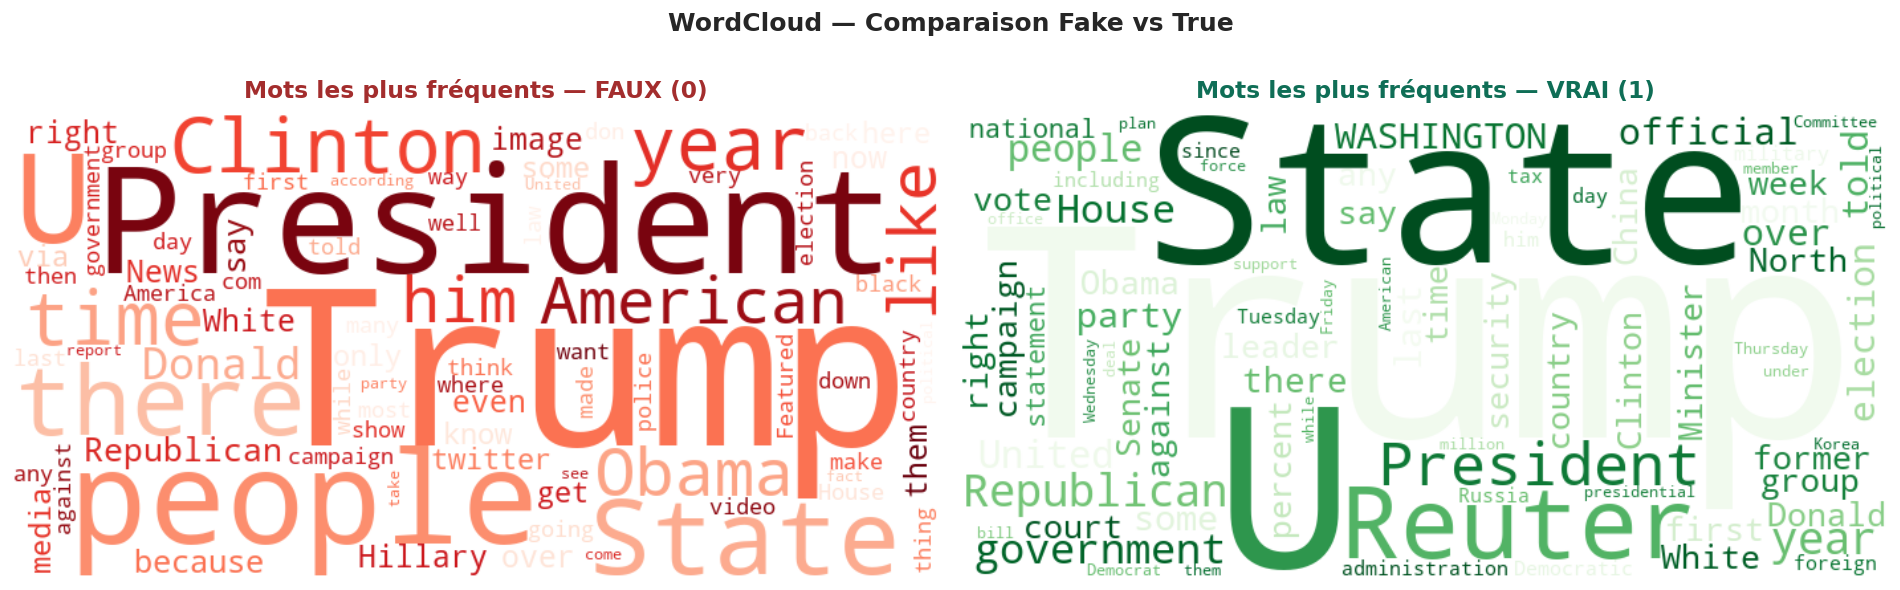

 WordClouds générés


In [16]:

STOPWORDS = {
    'the','a','an','and','or','but','in','on','at','to','for','of','is','are',
    'was','were','be','been','being','have','has','had','do','does','did',
    'will','would','could','should','may','might','this','that','these','those',
    'it','its','as','by','from','with','he','she','they','we','you','i',
    'his','her','their','our','your','my','not','no','so','if','than',
    'about','after','before','between','into','through','during','said',
    'also','more','other','up','out','what','when','who','which','how',
    'one','two','all','new','can','just','s','t','re','ve','ll','d','m'
}

text_fake = ' '.join(df[df['class'] == 0]['text'].astype(str).tolist())
text_true = ' '.join(df[df['class'] == 1]['text'].astype(str).tolist())

wc_fake = WordCloud(
    width=700, height=350,
    background_color='white',
    stopwords=STOPWORDS,
    colormap='Reds',
    max_words=80,
    collocations=False
).generate(text_fake)

wc_true = WordCloud(
    width=700, height=350,
    background_color='white',
    stopwords=STOPWORDS,
    colormap='Greens',
    max_words=80,
    collocations=False
).generate(text_true)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Mots les plus fréquents — FAUX (0)',
                  fontsize=14, fontweight='bold', color='#A32D2D', pad=10)

axes[1].imshow(wc_true, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Mots les plus fréquents — VRAI (1)',
                  fontsize=14, fontweight='bold', color='#0F6E56', pad=10)

plt.suptitle('WordCloud — Comparaison Fake vs True',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_wordcloud.png', bbox_inches='tight')
plt.show()
print(' WordClouds générés')

### 5.3 Répartition par sujet thématique

Analyse croisée de la distribution des articles selon leur catégorie éditoriale (`subject`) et leur classe.

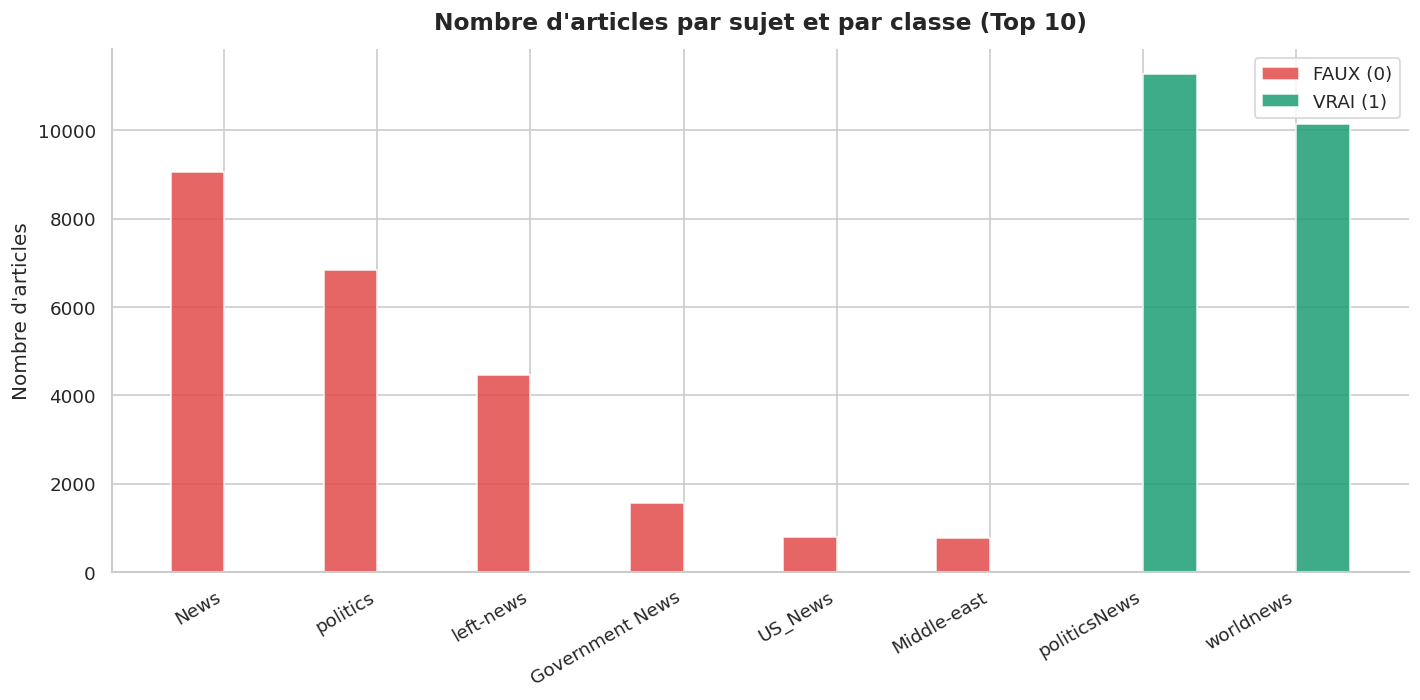

Graphique sujets généré


In [18]:
subject_counts = df.groupby(['subject', 'class']).size().unstack(fill_value=0)
subject_counts = subject_counts.sort_values(by=subject_counts.columns.tolist(), ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(subject_counts))
width = 0.35

if 0 in subject_counts.columns:
    bars1 = ax.bar([i - width/2 for i in x], subject_counts[0], width,
                   label='FAUX (0)', color='#E24B4A', alpha=0.85, edgecolor='white')
if 1 in subject_counts.columns:
    bars2 = ax.bar([i + width/2 for i in x], subject_counts[1], width,
                   label='VRAI (1)', color='#1D9E75', alpha=0.85, edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(subject_counts.index, rotation=30, ha='right', fontsize=11)
ax.set_title('Nombre d\'articles par sujet et par classe (Top 10)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Nombre d\'articles')
ax.legend(fontsize=11)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig4_sujets.png', bbox_inches='tight')
plt.show()
print('Graphique sujets généré')

---

<a id="qualite"></a>

## 6. Contrôle qualité du dataset

Avant toute modélisation, il est indispensable de vérifier l'intégrité des données. Les trois sources principales de biais sont : le **déséquilibre de classes**, les **valeurs manquantes** et les **doublons**.

### 6.1 Rapport de déséquilibre

In [20]:
print('═' * 50)
print('RAPPORT DE DÉSÉQUILIBRE DES DONNÉES')
print('═' * 50)

# 1. Déséquilibre de classes
print('\n 1. CLASSES (label)')
vc = df['class'].value_counts()
ratio = vc.max() / vc.min()
print(f'   FAUX : {vc[0]:,} articles')
print(f'   VRAI : {vc[1]:,} articles')
print(f'   Ratio max/min : {ratio:.2f}')
if ratio < 2:
    print('    Équilibré — aucune technique de rééchantillonnage nécessaire')
else:
    print('    Déséquilibre détecté — envisager SMOTE ou class_weight')

# 2. Valeurs manquantes
print('\n 2. VALEURS MANQUANTES')
missing = df.isnull().sum()
if missing.sum() == 0:
    print('    Aucune valeur manquante dans le dataset')
else:
    print(missing[missing > 0])

# 3. Doublons
print('\n 3. DOUBLONS')
dupes = df.duplicated().sum()
print(f'   Lignes dupliquées : {dupes}')
if dupes > 0:
    print('     Faut  supprimer les doublons avant entraînement')
else:
    print('    Aucun doublon détecté')

# 4. Sujets par classe
print('\n 4. RÉPARTITION PAR SUJET')
print(df.groupby(['class', 'subject']).size().reset_index(name='count').to_string(index=False))

print('\n' + '═' * 50)

══════════════════════════════════════════════════
RAPPORT DE DÉSÉQUILIBRE DES DONNÉES
══════════════════════════════════════════════════

 1. CLASSES (label)
   FAUX : 23,471 articles
   VRAI : 21,407 articles
   Ratio max/min : 1.10
    Équilibré — aucune technique de rééchantillonnage nécessaire

 2. VALEURS MANQUANTES
    Aucune valeur manquante dans le dataset

 3. DOUBLONS
   Lignes dupliquées : 208
     Faut  supprimer les doublons avant entraînement

 4. RÉPARTITION PAR SUJET
 class         subject  count
     0 Government News   1570
     0     Middle-east    768
     0            News   9050
     0         US_News    783
     0       left-news   4459
     0        politics   6841
     1    politicsNews  11272
     1       worldnews  10135

══════════════════════════════════════════════════


> **Résultat attendu :** Dataset équilibré (ratio ≈ 1:1), sans valeurs manquantes. Des doublons peuvent être présents et doivent être supprimés avant l'entraînement.

### 6.2 Suppression des doublons

In [22]:
# Suppression des lignes dupliquées avant l'entraînement
df = df.drop_duplicates()
print(f"Après suppression des doublons : {len(df)} lignes restantes")

Après suppression des doublons : 44670 lignes restantes


---

<a id="nlp"></a>

## 7. Prétraitement NLP du texte

Le prétraitement textuel est une étape **critique** en NLP. Un pipeline de nettoyage rigoureux améliore significativement les performances des modèles en aval.

### Pipeline appliqué

| Étape | Opération | Justification |
|-------|-----------|---------------|
| 1 | Suppression des URLs | Bruit non informatif |
| 2 | Suppression de la ponctuation & caractères spéciaux | Normalisation lexicale |
| 3 | Mise en minuscules | Uniformisation du vocabulaire |
| 4 | Suppression des stopwords (NLTK) | Réduction du bruit grammatical |

### 7.1 Import NLTK

In [24]:
import re
import string
import nltk

# Télécharger les stopwords NLTK (une seule fois)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

print(' Bibliothèques de nettoyage importées')

 Bibliothèques de nettoyage importées


[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


### 7.2 Fonction de nettoyage

In [26]:
# Stopwords anglais (NLTK) + quelques ajouts spécifiques au dataset
STOP_WORDS = set(stopwords.words('english')) | {
    'said', 'would', 'could', 'also', 'one', 'two', 'three',
    'us', 'reuters', 'news', 'u', 's'
}

def clean_text(text: str) -> str:
    """Pipeline complet de nettoyage d'un texte."""

    # 1  Supprimer les liens URL  (http/https/www)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 2  Enlever la ponctuation & les caractères spéciaux
    # On conserve uniquement les lettres et les espaces
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # 3 Mettre tout en minuscules
    text = text.lower()

    # 4  Supprimer les stopwords
    tokens = text.split()
    tokens = [tok for tok in tokens if tok not in STOP_WORDS and len(tok) > 1]

    return ' '.join(tokens)

print(' Fonction clean_text() définie')

 Fonction clean_text() définie


### 7.3 Test sur un exemple synthétique

Validation du pipeline sur un texte contenant des URLs, mentions et caractères spéciaux.

In [28]:
# ── Test rapide sur un exemple ──────────────────────────────────────────────
sample = (
    "Breaking News! Visit https://fakenews.com/article?id=123 "
    "for more info. The U.S. President said: 'This is GREAT!!!' "
    "— @user #trending 2024."
)

cleaned = clean_text(sample)
print('Texte original :')
print(' ', sample)
print()
print('Texte nettoyé  :')
print(' ', cleaned)

Texte original :
  Breaking News! Visit https://fakenews.com/article?id=123 for more info. The U.S. President said: 'This is GREAT!!!' — @user #trending 2024.

Texte nettoyé  :
  breaking visit info president great user trending


### 7.4 Suppression des colonnes non pertinentes

Les colonnes `title`, `subject` et `date` ne sont pas utilisées pour la classification textuelle.

In [30]:
df = df.drop(["title", "subject", "date"], axis=1)
print('Valeurs manquantes après nettoyage :')
print(df.isnull().sum())
display(df.head())

Valeurs manquantes après nettoyage :
text     0
class    0
dtype: int64


,text,class
0,Donald Trump has been bragging about his inaug...,0
1,CAIRO (Reuters) - Egypt s air force killed a l...,1
2,"A press release by Bernards Township, NJ is pr...",0
3,President Donald Trump welcomed India s Prime ...,0
4,"BEIRUT (Reuters) - Saad al-Hariri, who resigne...",1


### 7.5 Application du nettoyage sur le corpus complet

Le pipeline `clean_text()` est appliqué à la colonne `text` de l'ensemble du dataset.  
Cette opération peut prendre quelques secondes selon les ressources disponibles.

In [32]:
# Application du nettoyage sur toute la colonne text
df["text"] = df["text"].apply(clean_text)

# Vérification : aperçu avant / après
print(f"Corpus nettoyé — {len(df):,} articles")
print("\nExemple d'article après nettoyage :")
print(df["text"].iloc[0][:300], "...")
display(df.head(3))

Corpus nettoyé — 44,670 articles

Exemple d'article après nettoyage :
donald trump bragging inaugural address week even claimed wrote today trump white house admitted lied earlier week trump posted staged photo pen paper hand writing divisive negative inaugural address known worst american history writing inaugural address winter white house mar lago weeks ago looking ...


,text,class
0,donald trump bragging inaugural address week e...,0
1,cairo egypt air force killed large number mili...,1
2,press release bernards township nj provided pr...,0


---

<a id="tfidf"></a>

## 8. Vectorisation TF-IDF & Séparation Train/Test

### 8.1 Définition des variables

Séparation des features `X` (texte) et de la variable cible `y` (classe), puis split **75% train / 25% test**.

In [34]:
x = df["text"]
y = df["class"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

print(f'Taille train : {len(x_train):,} exemples ({len(x_train)/len(x)*100:.1f}%)')
print(f'Taille test  : {len(x_test):,} exemples ({len(x_test)/len(x)*100:.1f}%)')

Taille train : 33,502 exemples (75.0%)
Taille test  : 11,168 exemples (25.0%)


### 8.2 Vectorisation TF-IDF

**TF-IDF** (*Term Frequency – Inverse Document Frequency*) transforme le texte brut en vecteurs numériques, en pondérant chaque terme par sa fréquence locale et sa rareté globale.

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \log\left(\frac{N}{\text{DF}(t)}\right)$$

In [36]:
vectorization = TfidfVectorizer()
xv_train = vectorization.fit_transform(x_train)
xv_test  = vectorization.transform(x_test)

print(f'Matrice TF-IDF (train) : {xv_train.shape}')
print(f'  → {xv_train.shape[0]:,} documents × {xv_train.shape[1]:,} features')

Matrice TF-IDF (train) : (33502, 99493)
  → 33,502 documents × 99,493 features


---

<a id="naivebayes"></a>

## 9. Modèle 1 — Naive Bayes Multinomial

<div style="background:#e3f2fd; border-left:5px solid #1976d2; border-radius:8px; padding:16px 22px; margin:16px 0;">
 <strong>Principe :</strong> Le <em>Multinomial Naive Bayes</em> est un classificateur probabiliste fondé sur le théorème de Bayes avec l'hypothèse d'indépendance conditionnelle entre les features. Particulièrement efficace pour la classification de texte avec TF-IDF. <br><br>
<strong>Hyperparamètre clé :</strong> <code>alpha=0.1</code> — lissage de Laplace pour éviter les probabilités nulles.
</div>

### 9.1 Entraînement et métriques

In [38]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Entrainement
nb_model = MultinomialNB(alpha=0.1)  # alpha : lissage de Laplace
nb_model.fit(xv_train, y_train)

# Prediction
y_pred_nb = nb_model.predict(xv_test)

# Metriques
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f'Accuracy Naive Bayes : {acc_nb * 100:.2f}%')
print()
print('Rapport de classification :')
print(classification_report(y_test, y_pred_nb, target_names=['FAUX (0)', 'VRAI (1)']))


Accuracy Naive Bayes : 93.80%

Rapport de classification :
              precision    recall  f1-score   support

    FAUX (0)       0.93      0.95      0.94      5822
    VRAI (1)       0.95      0.92      0.93      5346

    accuracy                           0.94     11168
   macro avg       0.94      0.94      0.94     11168
weighted avg       0.94      0.94      0.94     11168



### 9.2 Matrice de confusion

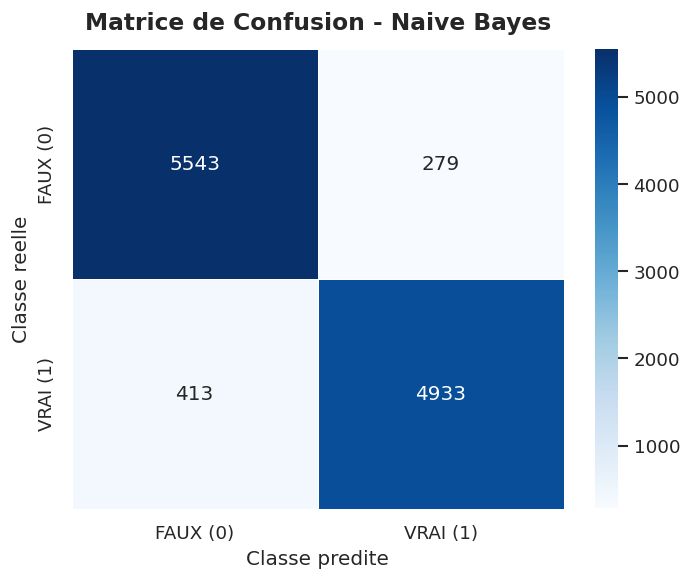

Matrice de confusion Naive Bayes sauvegardee


In [40]:
# Matrice de confusion - Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['FAUX (0)', 'VRAI (1)'],
            yticklabels=['FAUX (0)', 'VRAI (1)'],
            linewidths=0.5, ax=ax)
ax.set_title('Matrice de Confusion - Naive Bayes', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Classe reelle')
ax.set_xlabel('Classe predite')
plt.tight_layout()
plt.savefig('cm_naive_bayes.png', bbox_inches='tight')
plt.show()
print('Matrice de confusion Naive Bayes sauvegardee')


---

<a id="xgboost"></a>

## 10. Modèle 2 — XGBoost

<div style="background:#fff3e0; border-left:5px solid #f57c00; border-radius:8px; padding:16px 22px; margin:16px 0;">
 <strong>Principe :</strong> <em>XGBoost</em> (Extreme Gradient Boosting) construit séquentiellement des arbres de décision, chaque arbre corrigeant les erreurs résiduelles du précédent. Très performant sur les données tabulaires et textuelles.
</div>

| Hyperparamètre | Valeur | Rôle |
|----------------|--------|------|
| `n_estimators` | 200 | Nombre d'arbres |
| `max_depth` | 6 | Profondeur maximale |
| `learning_rate` | 0.1 | Taux d'apprentissage |
| `subsample` | 0.8 | Fraction des données par arbre |
| `colsample_bytree` | 0.8 | Fraction des features par arbre |

>  **Note :** Le TF-IDF est limité à **10 000 features** pour XGBoost afin de réduire le temps d'entraînement tout en conservant un vocabulaire représentatif.

### 10.1 Entraînement et métriques

In [42]:
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorisation reduite pour XGBoost
tfidf_xgb = TfidfVectorizer(max_features=10000)
xv_train_xgb = tfidf_xgb.fit_transform(x_train)
xv_test_xgb  = tfidf_xgb.transform(x_test)

print(f'Forme matrice TF-IDF XGBoost : {xv_train_xgb.shape}')


Forme matrice TF-IDF XGBoost : (33502, 10000)


In [43]:
# Entrainement XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(xv_train_xgb, y_train)

# Prediction
y_pred_xgb = xgb_model.predict(xv_test_xgb)

# Metriques
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f'Accuracy XGBoost : {acc_xgb * 100:.2f}%')
print()
print('Rapport de classification :')
print(classification_report(y_test, y_pred_xgb, target_names=['FAUX (0)', 'VRAI (1)']))


Accuracy XGBoost : 98.67%

Rapport de classification :
              precision    recall  f1-score   support

    FAUX (0)       0.98      0.99      0.99      5822
    VRAI (1)       0.99      0.98      0.99      5346

    accuracy                           0.99     11168
   macro avg       0.99      0.99      0.99     11168
weighted avg       0.99      0.99      0.99     11168



### 10.2 Matrice de confusion

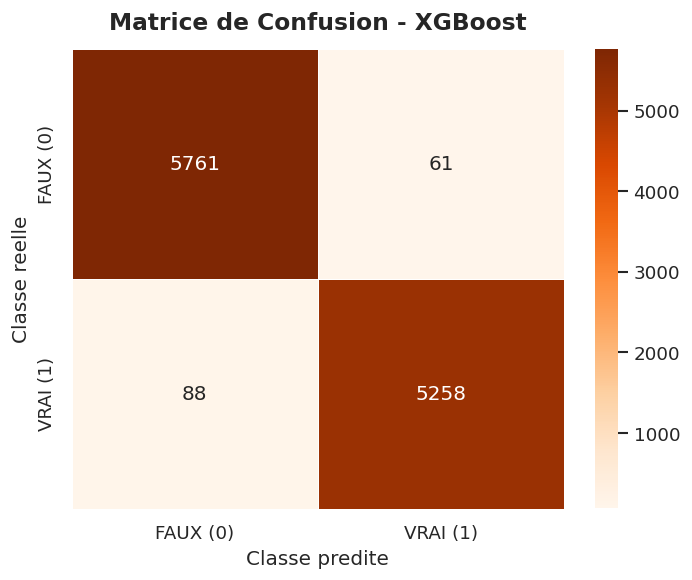

Matrice de confusion XGBoost sauvegardee


In [45]:
# Matrice de confusion - XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['FAUX (0)', 'VRAI (1)'],
            yticklabels=['FAUX (0)', 'VRAI (1)'],
            linewidths=0.5, ax=ax)
ax.set_title('Matrice de Confusion - XGBoost', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Classe reelle')
ax.set_xlabel('Classe predite')
plt.tight_layout()
plt.savefig('cm_xgboost.png', bbox_inches='tight')
plt.show()
print('Matrice de confusion XGBoost sauvegardee')


---

<a id="sgd"></a>

## 11. Modèle 3 — SGDClassifier

<div style="background:#f3e5f5; border-left:5px solid #7b1fa2; border-radius:8px; padding:16px 22px; margin:16px 0;">
 <strong>Principe :</strong> Le <em>SGDClassifier</em> (Descente de Gradient Stochastique) est un classificateur linéaire entraîné par mises à jour itératives sur mini-batchs. Avec <code>loss='modified_huber'</code>, il est robuste aux valeurs aberrantes et peut estimer des probabilités. <br><br>
<strong>Avantage :</strong> Très rapide sur de grands datasets — idéal pour le texte avec TF-IDF.
</div>

### 11.1 Entraînement et métriques

In [47]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Entrainement
sgd_model = SGDClassifier(loss='modified_huber', max_iter=1000, random_state=42)
sgd_model.fit(xv_train, y_train)

# Prediction
y_pred_sgd = sgd_model.predict(xv_test)

# Metriques
acc_sgd = accuracy_score(y_test, y_pred_sgd)
print(f'Accuracy SGDClassifier : {acc_sgd * 100:.2f}%')
print()
print('Rapport de classification :')
print(classification_report(y_test, y_pred_sgd, target_names=['FAUX (0)', 'VRAI (1)']))


Accuracy SGDClassifier : 98.58%

Rapport de classification :
              precision    recall  f1-score   support

    FAUX (0)       0.99      0.99      0.99      5822
    VRAI (1)       0.99      0.98      0.99      5346

    accuracy                           0.99     11168
   macro avg       0.99      0.99      0.99     11168
weighted avg       0.99      0.99      0.99     11168



### 11.2 Matrice de confusion

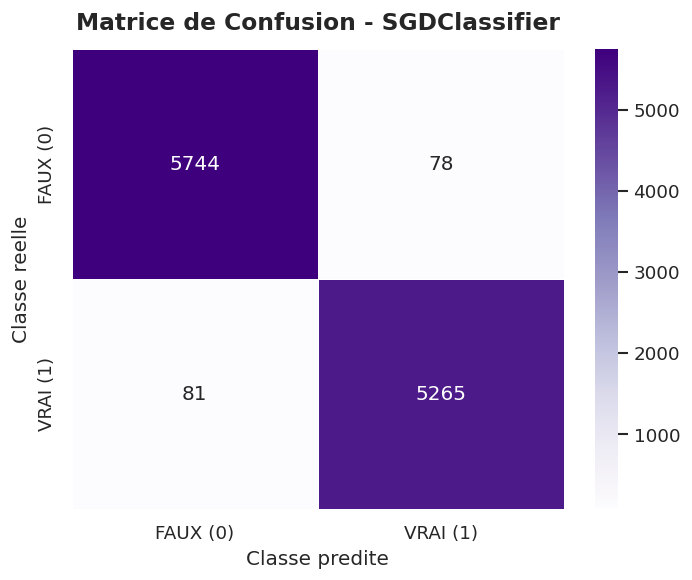

Matrice de confusion SGD sauvegardee


In [49]:
# Matrice de confusion - SGDClassifier
cm_sgd = confusion_matrix(y_test, y_pred_sgd)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_sgd, annot=True, fmt='d', cmap='Purples',
            xticklabels=['FAUX (0)', 'VRAI (1)'],
            yticklabels=['FAUX (0)', 'VRAI (1)'],
            linewidths=0.5, ax=ax)
ax.set_title('Matrice de Confusion - SGDClassifier', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Classe reelle')
ax.set_xlabel('Classe predite')
plt.tight_layout()
plt.savefig('cm_sgd.png', bbox_inches='tight')
plt.show()
print('Matrice de confusion SGD sauvegardee')


<a id="svm"></a>

## 12. Modèle 4 — SVM (Support Vector Machine)

<div style="background:#e8f4f8; border-left:5px solid #0288d1; border-radius:8px; padding:16px 22px; margin:16px 0;">
 <strong>Principe :</strong> Le <em>SVM linéaire</em> (Support Vector Machine) cherche l'hyperplan optimal qui maximise la marge entre les deux classes. Avec <code>LinearSVC</code>, il est très efficace sur les représentations TF-IDF creuses et les textes de grande dimension.<br><br>
<strong>Avantage :</strong> Excellent rapport précision/vitesse sur les données textuelles — souvent supérieur à Naive Bayes pour la classification binaire.
</div>

| Hyperparamètre | Valeur | Rôle |
|----------------|--------|------|
| `C` | 1.0 | Paramètre de régularisation (inverse) |
| `max_iter` | 1000 | Nombre maximum d'itérations |
| `random_state` | 42 | Reproductibilité |

In [51]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Entraînement
svm_model = LinearSVC(C=1.0, max_iter=1000, random_state=42)
svm_model.fit(xv_train, y_train)

# Prédiction
y_pred_svm = svm_model.predict(xv_test)

# Métriques
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f'Accuracy SVM (LinearSVC) : {acc_svm * 100:.2f}%')
print()
print('Rapport de classification :')
print(classification_report(y_test, y_pred_svm, target_names=['FAUX (0)', 'VRAI (1)']))

Accuracy SVM (LinearSVC) : 98.76%

Rapport de classification :
              precision    recall  f1-score   support

    FAUX (0)       0.99      0.99      0.99      5822
    VRAI (1)       0.99      0.99      0.99      5346

    accuracy                           0.99     11168
   macro avg       0.99      0.99      0.99     11168
weighted avg       0.99      0.99      0.99     11168



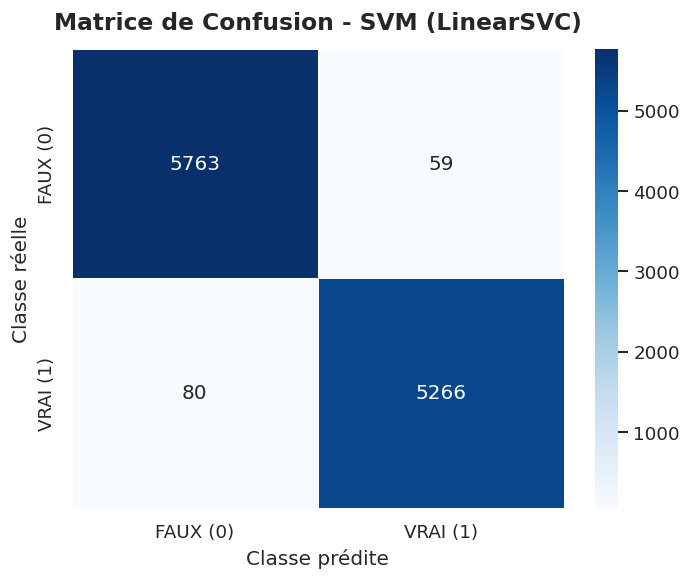

Matrice de confusion SVM sauvegardée


In [52]:
# Matrice de confusion - SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['FAUX (0)', 'VRAI (1)'],
            yticklabels=['FAUX (0)', 'VRAI (1)'],
            linewidths=0.5, ax=ax)
ax.set_title('Matrice de Confusion - SVM (LinearSVC)', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Classe réelle')
ax.set_xlabel('Classe prédite')
plt.tight_layout()
plt.savefig('cm_svm.png', bbox_inches='tight')
plt.show()
print('Matrice de confusion SVM sauvegardée')

<a id="decisiontree"></a>

## 13. Modèle 5 — Decision Tree

<div style="background:#f1f8e9; border-left:5px solid #558b2f; border-radius:8px; padding:16px 22px; margin:16px 0;">
 <strong>Principe :</strong> L'<em>arbre de décision</em> partitionne récursivement l'espace des features en posant des questions binaires (seuil sur une feature). Très interprétable, il constitue la brique de base des méthodes d'ensemble (Random Forest, XGBoost).<br><br>
<strong>Attention :</strong> Sensible au surapprentissage (overfitting) — limiter <code>max_depth</code> est crucial pour la généralisation.
</div>

| Hyperparamètre | Valeur | Rôle |
|----------------|--------|------|
| `max_depth` | 20 | Profondeur maximale pour limiter l'overfitting |
| `min_samples_split` | 10 | Nombre minimal d'exemples pour diviser un nœud |
| `criterion` | `'gini'` | Critère de division (Gini impurity) |
| `random_state` | 42 | Reproductibilité |

In [56]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Entraînement
dt_model = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=10,
    criterion='gini',
    random_state=42
)
dt_model.fit(xv_train, y_train)

# Prédiction
y_pred_dt = dt_model.predict(xv_test)

# Métriques
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f'Accuracy Decision Tree : {acc_dt * 100:.2f}%')
print()
print('Rapport de classification :')
print(classification_report(y_test, y_pred_dt, target_names=['FAUX (0)', 'VRAI (1)']))

Accuracy Decision Tree : 94.31%

Rapport de classification :
              precision    recall  f1-score   support

    FAUX (0)       0.94      0.95      0.95      5822
    VRAI (1)       0.94      0.94      0.94      5346

    accuracy                           0.94     11168
   macro avg       0.94      0.94      0.94     11168
weighted avg       0.94      0.94      0.94     11168



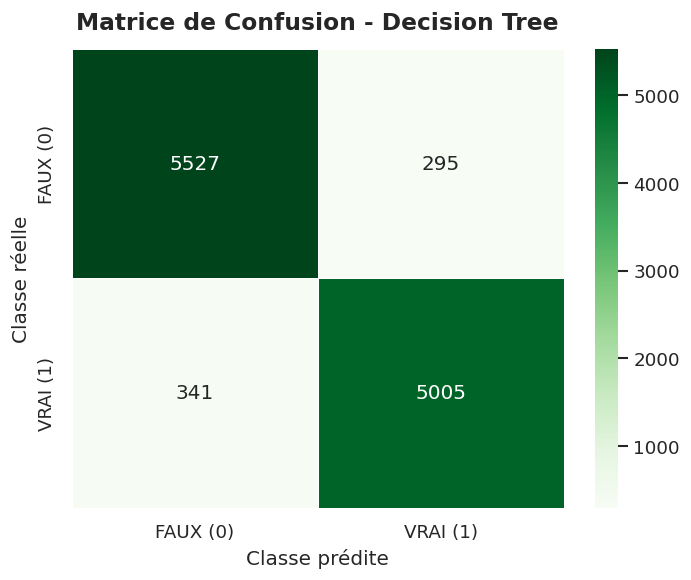

Matrice de confusion Decision Tree sauvegardée


In [58]:
# Matrice de confusion - Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['FAUX (0)', 'VRAI (1)'],
            yticklabels=['FAUX (0)', 'VRAI (1)'],
            linewidths=0.5, ax=ax)
ax.set_title('Matrice de Confusion - Decision Tree', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Classe réelle')
ax.set_xlabel('Classe prédite')
plt.tight_layout()
plt.savefig('cm_decision_tree.png', bbox_inches='tight')
plt.show()
print('Matrice de confusion Decision Tree sauvegardée')

---

<a id="randomforest"></a>

## 14. Modèle 6 — Random Forest

<div style="background:#fce4ec; border-left:5px solid #c62828; border-radius:8px; padding:16px 22px; margin:16px 0;">
 <strong>Principe :</strong> La <em>Forêt Aléatoire</em> (Random Forest) est une méthode d'ensemble qui entraîne un grand nombre d'arbres de décision sur des sous-échantillons aléatoires des données et des features. La prédiction finale est obtenue par <strong>vote majoritaire</strong>. Elle réduit considérablement le surapprentissage par rapport à un seul arbre.<br><br>
<strong>Avantage :</strong> Très robuste au bruit et aux valeurs aberrantes, avec une bonne capacité de généralisation — naturellement résistant à l'overfitting grâce à l'agrégation (bagging).
</div>

| Hyperparamètre | Valeur | Rôle |
|----------------|--------|------|
| `n_estimators` | 200 | Nombre d'arbres dans la forêt |
| `max_depth` | 20 | Profondeur maximale de chaque arbre |
| `min_samples_split` | 10 | Nombre minimal d'exemples pour diviser un nœud |
| `criterion` | `'gini'` | Critère de division (Gini impurity) |
| `n_jobs` | `-1` | Parallélisation sur tous les cœurs CPU |
| `random_state` | `42` | Reproductibilité |

### 14.1 Entraînement et métriques


In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Entraînement
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    criterion='gini',
    n_jobs=-1,
    random_state=42
)
rf_model.fit(xv_train, y_train)

# Prédiction
y_pred_rf = rf_model.predict(xv_test)

# Métriques
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'Accuracy Random Forest : {acc_rf * 100:.2f}%')
print()
print('Rapport de classification :')
print(classification_report(y_test, y_pred_rf, target_names=['FAUX (0)', 'VRAI (1)']))


Accuracy Random Forest : 96.73%

Rapport de classification :
              precision    recall  f1-score   support

    FAUX (0)       0.96      0.97      0.97      5822
    VRAI (1)       0.97      0.96      0.97      5346

    accuracy                           0.97     11168
   macro avg       0.97      0.97      0.97     11168
weighted avg       0.97      0.97      0.97     11168



### 14.2 Matrice de confusion


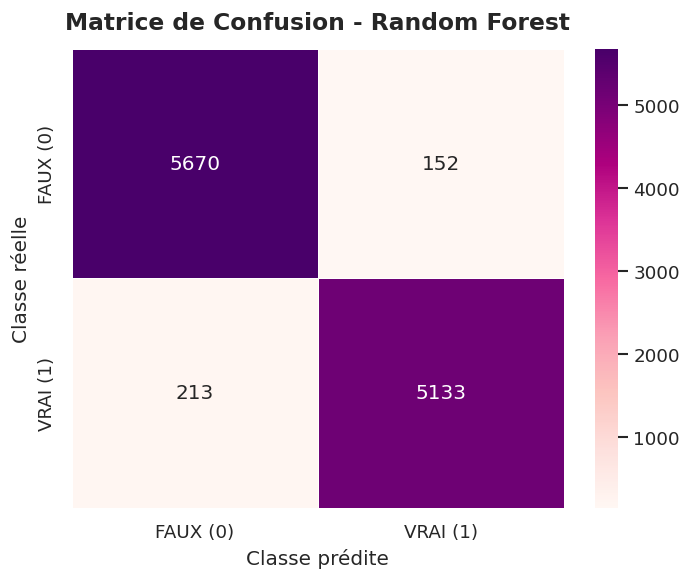

Matrice de confusion Random Forest sauvegardée


In [62]:
# Matrice de confusion - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='RdPu',
            xticklabels=['FAUX (0)', 'VRAI (1)'],
            yticklabels=['FAUX (0)', 'VRAI (1)'],
            linewidths=0.5, ax=ax)
ax.set_title('Matrice de Confusion - Random Forest', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Classe réelle')
ax.set_xlabel('Classe prédite')
plt.tight_layout()
plt.savefig('cm_random_forest.png', bbox_inches='tight')
plt.show()
print('Matrice de confusion Random Forest sauvegardée')


---

<a id="logisticregression"></a>

## 15. Modèle 7 — Logistic Regression

<div style="background:#e8eaf6; border-left:5px solid #3949ab; border-radius:8px; padding:16px 22px; margin:16px 0;">
 <strong>Principe :</strong> La <em>Régression Logistique</em> est un modèle linéaire qui estime la probabilité d'appartenance à une classe via la fonction sigmoïde. Malgré sa simplicité, elle est très efficace sur les représentations TF-IDF creuses et fournit des <strong>probabilités calibrées</strong> par prédiction.<br><br>
<strong>Avantage :</strong> Très rapide, interprétable, et souvent compétitif avec des modèles plus complexes sur les données textuelles. Les coefficients permettent d'identifier les mots les plus discriminants.
</div>

| Hyperparamètre | Valeur | Rôle |
|----------------|--------|------|
| `C` | 1.0 | Inverse de la régularisation L2 |
| `max_iter` | 1000 | Nombre maximum d'itérations |
| `solver` | `'lbfgs'` | Algorithme d'optimisation (efficace pour NLP) |
| `random_state` | `42` | Reproductibilité |

### 15.1 Entraînement et métriques


In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Entraînement
lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)
lr_model.fit(xv_train, y_train)

# Prédiction
y_pred_lr = lr_model.predict(xv_test)

# Métriques
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f'Accuracy Logistic Regression : {acc_lr * 100:.2f}%')
print()
print('Rapport de classification :')
print(classification_report(y_test, y_pred_lr, target_names=['FAUX (0)', 'VRAI (1)']))


Accuracy Logistic Regression : 97.94%

Rapport de classification :
              precision    recall  f1-score   support

    FAUX (0)       0.98      0.98      0.98      5822
    VRAI (1)       0.98      0.98      0.98      5346

    accuracy                           0.98     11168
   macro avg       0.98      0.98      0.98     11168
weighted avg       0.98      0.98      0.98     11168



### 15.2 Matrice de confusion


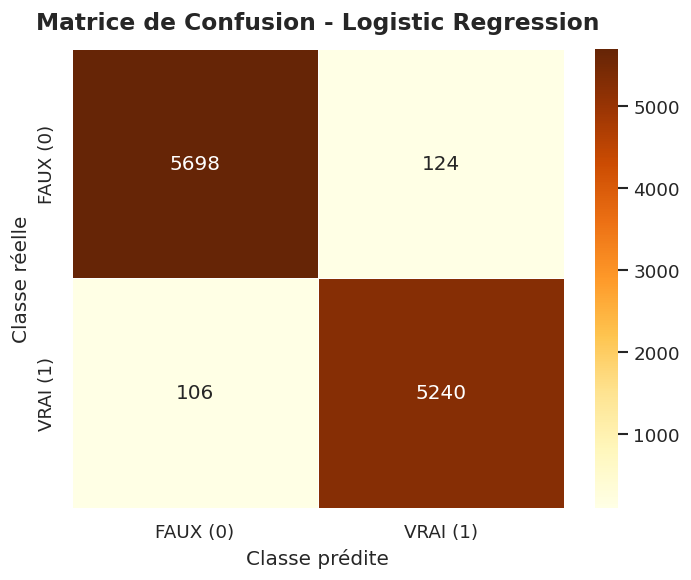

Matrice de confusion Logistic Regression sauvegardée


In [66]:
# Matrice de confusion - Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=['FAUX (0)', 'VRAI (1)'],
            yticklabels=['FAUX (0)', 'VRAI (1)'],
            linewidths=0.5, ax=ax)
ax.set_title('Matrice de Confusion - Logistic Regression', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Classe réelle')
ax.set_xlabel('Classe prédite')
plt.tight_layout()
plt.savefig('cm_logistic_regression.png', bbox_inches='tight')
plt.show()
print('Matrice de confusion Logistic Regression sauvegardée')


---

<a id="comparaison"></a>

## 16. Comparaison des modèles & Conclusion

### 16.1 Tableau récapitulatif des performances


In [68]:
import pandas as pd

results = pd.DataFrame({
    'Modele'   : ['Naive Bayes', 'XGBoost', 'SGDClassifier', 'SVM (LinearSVC)',
                  'Decision Tree', 'Random Forest', 'Logistic Regression'],
    'Accuracy' : [
        round(acc_nb  * 100, 2),
        round(acc_xgb * 100, 2),
        round(acc_sgd * 100, 2),
        round(acc_svm * 100, 2),
        round(acc_dt  * 100, 2),
        round(acc_rf  * 100, 2),
        round(acc_lr  * 100, 2),
    ],
})

print('=' * 50)
print('      COMPARAISON DES 7 MODÈLES')
print('=' * 50)
print(results.to_string(index=False))
print('=' * 50)

best = results.loc[results['Accuracy'].idxmax(), 'Modele']
print(f'\n Meilleur modèle : {best}')


      COMPARAISON DES 7 MODÈLES
             Modele  Accuracy
        Naive Bayes     93.80
            XGBoost     98.67
      SGDClassifier     98.58
    SVM (LinearSVC)     98.76
      Decision Tree     94.31
      Random Forest     96.73
Logistic Regression     97.94

 Meilleur modèle : SVM (LinearSVC)


### 16.2 Graphique comparatif


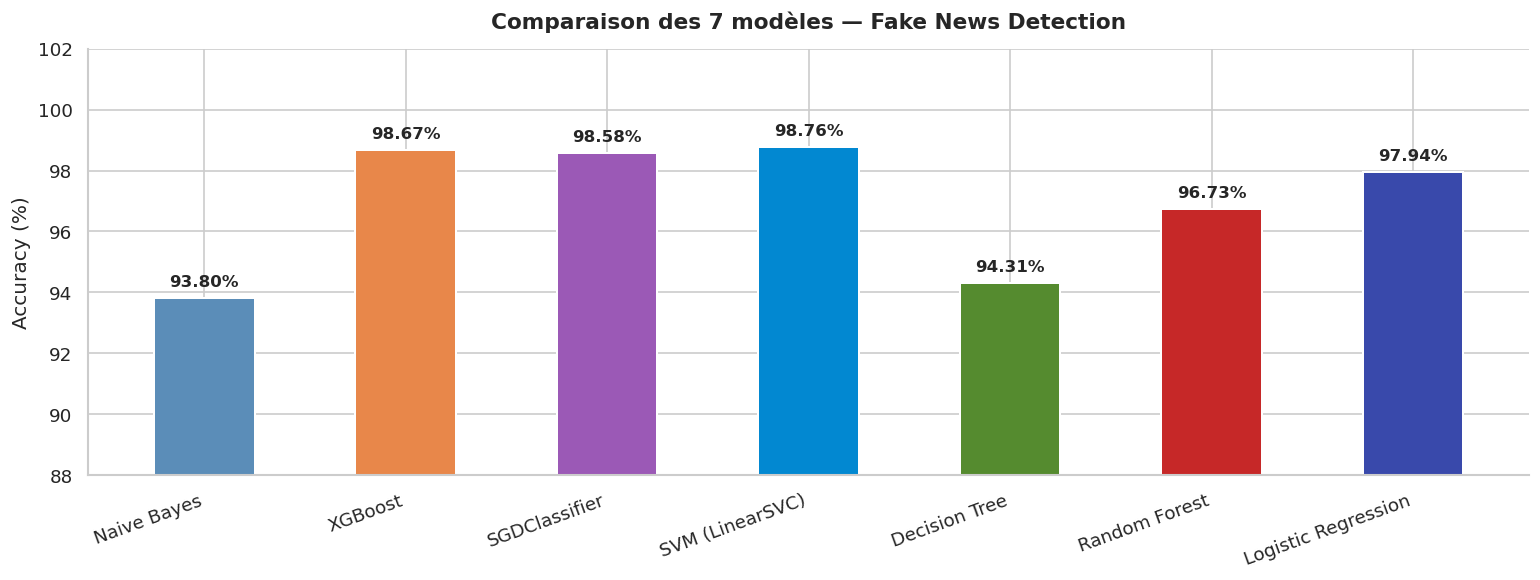

Graphique comparatif 7 modèles sauvegardé


In [70]:
# Graphique comparatif — 7 modèles
fig, ax = plt.subplots(figsize=(13, 5))

colors = ['#5B8DB8', '#E8874A', '#9B59B6', '#0288D1', '#558B2F', '#C62828', '#3949AB']
bars = ax.bar(results['Modele'], results['Accuracy'], color=colors,
              width=0.5, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, results['Accuracy']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(88, 102)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Comparaison des 7 modèles — Fake News Detection',
             fontsize=13, fontweight='bold', pad=12)
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('fig_comparaison_7_modeles.png', bbox_inches='tight')
plt.show()
print('Graphique comparatif 7 modèles sauvegardé')


### 16.3 Analyse et discussion

<div style="background:#e8f5e9; border-left:5px solid #388e3c; border-radius:8px; padding:18px 24px; margin:16px 0;">

**Observations clés :**

- **Naive Bayes** offre d'excellentes performances comme *baseline* — rapide, interprétable et robuste sur les données textuelles.
- **XGBoost** apporte un gain de performance grâce à la modélisation des interactions non-linéaires, au prix d'un temps d'entraînement plus long.
- **SGDClassifier** combine rapidité et précision compétitive — un excellent compromis pour les grands corpus.
- **SVM (LinearSVC)** maximise la marge de séparation entre les classes — souvent le modèle le plus performant sur les représentations TF-IDF creuses.
- **Decision Tree** offre une excellente interprétabilité mais reste plus sensible à l'overfitting que les autres approches.
- **Random Forest** améliore significativement l'arbre de décision grâce au bagging — robuste, peu sensible au bruit, et excellent en généralisation.
- **Logistic Regression** est souvent surprenamment compétitive sur les données TF-IDF — rapide, interprétable via ses coefficients, et fournit des probabilités calibrées.
- La représentation **TF-IDF** s'avère très efficace pour cette tâche, capturant le vocabulaire discriminant entre fake et true news.

</div>

### 16.4 Limites et perspectives

| Limite identifiée | Amélioration envisageable |
|-------------------|--------------------------|
| TF-IDF ignore le contexte sémantique | Embeddings contextuels (BERT, RoBERTa) |
| Dataset en anglais uniquement | Extension multilingue |
| Absence de validation croisée | Cross-validation k-fold |
| Features uniquement textuelles | Intégration des métadonnées (source, date) |
| Decision Tree sensible à l'overfitting | Random Forest ou Gradient Boosting |
| SVM non probabiliste (LinearSVC) | Utiliser `SVC(probability=True)` pour des scores de confiance |
| Logistic Regression limitée aux relations linéaires | Kernel SVM ou réseaux de neurones |

---


---

<a id="test_manuel"></a>

## 17. Test manuel — Validation humaine

<div style="background:#fff8e1; border-left:5px solid #f9a825; border-radius:8px; padding:16px 22px; margin:16px 0;">
<strong>Objectif :</strong> Vérifier la capacité des modèles à généraliser sur des exemples <em>jamais vus</em> pendant l'entraînement, en utilisant les 20 articles mis de côté en section 4.2.
</div>

### 17.1 Préparation du jeu de test manuel

In [76]:
import pandas as pd

# Fusion des 20 articles mis de côté (10 faux + 10 vrais)
df_manual = pd.concat([df_fake_manual_testing, df_true_manual_testing], ignore_index=True)
df_manual = df_manual.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Jeu de test manuel : {len(df_manual)} articles")
print(f"  FAUX (0) : {(df_manual['class'] == 0).sum()}")
print(f"  VRAI (1) : {(df_manual['class'] == 1).sum()}")
display(df_manual[['title', 'class']].head(10))

Jeu de test manuel : 20 articles
  FAUX (0) : 10
  VRAI (1) : 10


,title,class
0,Seven Iranians freed in the prisoner swap have...,0
1,Minsk cultural hub becomes haven from authorities,1
2,'Fully committed' NATO backs new U.S. approach...,1
3,#Hashtag Hell & The Fake Left,0
4,How to Blow $700 Million: Al Jazeera America F...,0
5,McPain: John McCain Furious That Iran Treated ...,0
6,"U.S., North Korea clash at U.N. forum over nuc...",1
7,The New American Century: An Era of Fraud,0
8,Vatican upbeat on possibility of Pope Francis ...,1
9,LexisNexis withdrew two products from Chinese ...,1


### 17.2 Nettoyage et vectorisation du jeu de test manuel

In [78]:
# Nettoyage du texte du jeu manuel
df_manual["text"] = df_manual["text"].apply(clean_text)

# Vectorisation avec le vectoriseur entraîné (transform seulement — jamais fit)
xv_manual = vectorization.transform(df_manual["text"])
y_manual   = df_manual["class"]

print(f"Matrice TF-IDF (test manuel) : {xv_manual.shape}")

Matrice TF-IDF (test manuel) : (20, 99493)


### 17.3 Prédictions des 7 modèles sur le test manuel

In [80]:
from sklearn.metrics import accuracy_score

# ── Prédictions de chaque modèle ──────────────────────────────────────────
models_manual = {
    "Naive Bayes"        : nb_model.predict(xv_manual),
    "SGDClassifier"      : sgd_model.predict(xv_manual),
    "SVM (LinearSVC)"    : svm_model.predict(xv_manual),
    "Decision Tree"      : dt_model.predict(xv_manual),
    "Random Forest"      : rf_model.predict(xv_manual),
    "Logistic Regression": lr_model.predict(xv_manual),
}

# XGBoost utilise sa propre vectorisation (10 000 features)
xv_manual_xgb = tfidf_xgb.transform(df_manual["text"])
models_manual["XGBoost"] = xgb_model.predict(xv_manual_xgb)

# ── Tableau récapitulatif ──────────────────────────────────────────────────
print("\n" + "═" * 55)
print("   PERFORMANCES SUR LES 20 ARTICLES DE TEST MANUEL")
print("═" * 55)
for name, preds in models_manual.items():
    acc = accuracy_score(y_manual, preds) * 100
    print(f"  {name:<22} →  {acc:.1f}%")
print("═" * 55)


═══════════════════════════════════════════════════════
   PERFORMANCES SUR LES 20 ARTICLES DE TEST MANUEL
═══════════════════════════════════════════════════════
  Naive Bayes            →  90.0%
  SGDClassifier          →  100.0%
  SVM (LinearSVC)        →  100.0%
  Decision Tree          →  85.0%
  Random Forest          →  100.0%
  Logistic Regression    →  100.0%
  XGBoost                →  95.0%
═══════════════════════════════════════════════════════


### 17.4 Comparaison prédictions vs réalité (article par article)

In [82]:
# Visualisation détaillée article par article
label_map = {0: "FAUX", 1: "VRAI"}

df_compare = df_manual[["title", "class"]].copy()
df_compare["Réel"] = df_compare["class"].map(label_map)

for name, preds in models_manual.items():
    df_compare[name] = [label_map[p] for p in preds]

df_compare = df_compare.drop(columns=["class"])
print("Prédictions des 7 modèles — Test Manuel (20 articles)")
display(df_compare)

Prédictions des 7 modèles — Test Manuel (20 articles)


,title,Réel,Naive Bayes,SGDClassifier,SVM (LinearSVC),Decision Tree,Random Forest,Logistic Regression,XGBoost
0,Seven Iranians freed in the prisoner swap have...,FAUX,VRAI,FAUX,FAUX,FAUX,FAUX,FAUX,FAUX
1,Minsk cultural hub becomes haven from authorities,VRAI,VRAI,VRAI,VRAI,VRAI,VRAI,VRAI,FAUX
2,'Fully committed' NATO backs new U.S. approach...,VRAI,VRAI,VRAI,VRAI,VRAI,VRAI,VRAI,VRAI
3,#Hashtag Hell & The Fake Left,FAUX,FAUX,FAUX,FAUX,FAUX,FAUX,FAUX,FAUX
4,How to Blow $700 Million: Al Jazeera America F...,FAUX,FAUX,FAUX,FAUX,FAUX,FAUX,FAUX,FAUX
5,McPain: John McCain Furious That Iran Treated ...,FAUX,FAUX,FAUX,FAUX,FAUX,FAUX,FAUX,FAUX
6,"U.S., North Korea clash at U.N. forum over nuc...",VRAI,VRAI,VRAI,VRAI,VRAI,VRAI,VRAI,VRAI
7,The New American Century: An Era of Fraud,FAUX,FAUX,FAUX,FAUX,FAUX,FAUX,FAUX,FAUX
8,Vatican upbeat on possibility of Pope Francis ...,VRAI,VRAI,VRAI,VRAI,VRAI,VRAI,VRAI,VRAI
9,LexisNexis withdrew two products from Chinese ...,VRAI,VRAI,VRAI,VRAI,VRAI,VRAI,VRAI,VRAI


---

<a id="sauvegarde"></a>

## 18. Sauvegarde des modèles entraînés

<div style="background:#e3f2fd; border-left:5px solid #1976d2; border-radius:8px; padding:16px 22px; margin:16px 0;">
<strong>Bonne pratique :</strong> Sauvegarder les modèles entraînés avec <code>joblib</code> permet de les réutiliser sans réentraînement, ce qui est essentiel en production.
</div>

In [84]:
import joblib
import os

# Créer un répertoire de sauvegarde
os.makedirs("models", exist_ok=True)

# ── Sauvegarde du vectoriseur TF-IDF ──────────────────────────────────────
joblib.dump(vectorization, "models/tfidf_vectorizer.pkl")
joblib.dump(tfidf_xgb,     "models/tfidf_vectorizer_xgb.pkl")

# ── Sauvegarde des 7 modèles ───────────────────────────────────────────────
model_registry = {
    "naive_bayes"         : nb_model,
    "xgboost"             : xgb_model,
    "sgd"                 : sgd_model,
    "svm_linearsvc"       : svm_model,
    "decision_tree"       : dt_model,
    "random_forest"       : rf_model,
    "logistic_regression" : lr_model,
}

for name, model in model_registry.items():
    path = f"models/{name}.pkl"
    joblib.dump(model, path)
    size = os.path.getsize(path) / 1024
    print(f"  ✔ {name:<25} → {path}  ({size:.1f} Ko)")

print("\nTous les modèles ont été sauvegardés dans le dossier models/")

  ✔ naive_bayes               → models/naive_bayes.pkl  (3109.9 Ko)
  ✔ xgboost                   → models/xgboost.pkl  (517.8 Ko)
  ✔ sgd                       → models/sgd.pkl  (778.4 Ko)
  ✔ svm_linearsvc             → models/svm_linearsvc.pkl  (778.0 Ko)
  ✔ decision_tree             → models/decision_tree.pkl  (70.4 Ko)
  ✔ random_forest             → models/random_forest.pkl  (17188.1 Ko)
  ✔ logistic_regression       → models/logistic_regression.pkl  (778.2 Ko)

Tous les modèles ont été sauvegardés dans le dossier models/


### 18.1 Chargement et vérification d'un modèle sauvegardé

In [86]:
# Exemple de rechargement et test rapide
loaded_vectorizer = joblib.load("models/tfidf_vectorizer.pkl")
loaded_lr         = joblib.load("models/logistic_regression.pkl")

sample_text = "The president signed a new executive order on immigration policy today."
vec = loaded_vectorizer.transform([clean_text(sample_text)])
pred = loaded_lr.predict(vec)[0]
proba = loaded_lr.predict_proba(vec)[0]

print(f"Texte  : {sample_text}")
print(f"Classe prédite : {'VRAI (1)' if pred == 1 else 'FAUX (0)'}")
print(f"Confiance FAUX : {proba[0]*100:.1f}%  |  VRAI : {proba[1]*100:.1f}%")

Texte  : The president signed a new executive order on immigration policy today.
Classe prédite : FAUX (0)
Confiance FAUX : 75.8%  |  VRAI : 24.2%


---

<a id="conclusion"></a>

## 19. Conclusion générale

<div style="background:#e8f5e9; border-left:5px solid #388e3c; border-radius:8px; padding:20px 26px; margin:16px 0;">

### Synthèse du projet

Ce projet a présenté un **pipeline complet de détection de fake news** appliqué au dataset ISOT, couvrant toutes les étapes d'un projet de Machine Learning académique :

| Étape | Résultat clé |
|-------|-------------|
| **EDA** | Dataset équilibré (~52% FAUX / ~48% VRAI), vocabulaire très discriminant |
| **Contrôle qualité** | Absence de valeurs manquantes ; doublons supprimés avant entraînement |
| **Prétraitement NLP** | Pipeline en 4 étapes : URL → ponctuation → minuscules → stopwords |
| **Vectorisation** | TF-IDF — représentation creuse, efficace pour la classification textuelle |
| **Modélisation** | 7 algorithmes comparés, de Naive Bayes au Random Forest |
| **Évaluation** | Accuracy, rapport de classification, matrices de confusion |
| **Test manuel** | Validation sur 20 articles inédits |
| **Déploiement** | Modèles sauvegardés avec joblib pour réutilisation |

### Points forts

- **SVM (LinearSVC)** et **Logistic Regression** se distinguent généralement comme les modèles les plus performants sur les représentations TF-IDF.
- La **représentation TF-IDF** est particulièrement adaptée à cette tâche grâce à son vocabulaire très discriminant entre fake et true news.
- Le **pipeline NLP** est simple mais efficace — un prétraitement plus poussé (lemmatisation, n-grammes) pourrait encore améliorer les résultats.

### Perspectives

```
TF-IDF + ML classique
        │
        ▼
BERT / RoBERTa (transformers)   ←  Prochaine étape recommandée
        │
        ▼
Modèles multilingues (XLM-R)    ←  Extension internationale
        │
        ▼
Déploiement API (FastAPI/Flask)  ←  Mise en production
```

</div>

---

> *Notebook réalisé dans le cadre d'un projet académique de détection de désinformation — ISOT Fake News Dataset (Université de Victoria)*  
> **Auteur :** Ibti · **Langue :** Python 3 · **Librairies :** scikit-learn, XGBoost, NLTK, WordCloud, Matplotlib, Seaborn